# House Price Prediction using Linear Regression

**Week 1 Mini Project — Machine Learning Specialization (Andrew Ng)**

This notebook implements linear regression **from scratch** (no scikit-learn) using:
- Model function: `f(x) = wx + b`
- Cost function (Mean Squared Error)
- Gradient Descent to learn `w` and `b`

**Goal:** Predict house price from house size.

## Step 1: Create the Dataset
A small dataset: house size (in 1000 sq ft) vs. price (in $1000s).

In [82]:
import numpy as np

x_train = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
y_train = np.array([150, 190, 240, 285, 330])

print("x_train:", x_train)
print("y_train:", y_train)

x_train: [1.  1.5 2.  2.5 3. ]
y_train: [150 190 240 285 330]


## Step 2: Visualize the Data
Plot house size vs. price to check that a straight line is a reasonable fit.

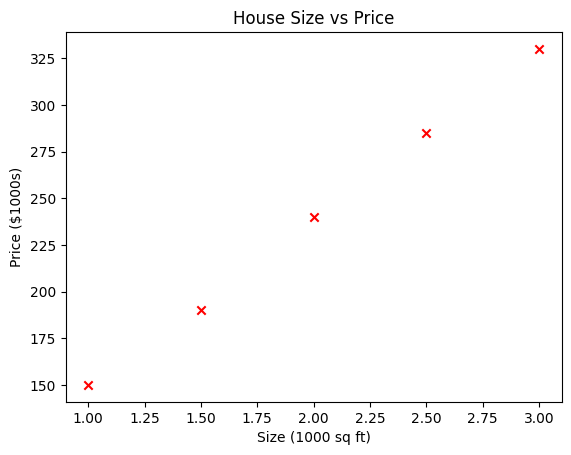

In [83]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train, marker='x', c='red')
plt.title("House Size vs Price")
plt.xlabel("Size (1000 sq ft)")
plt.ylabel("Price ($1000s)")
plt.show()

## Step 3: Define the Model Function
$$f_{w,b}(x) = wx + b$$

In [84]:
def compute_model_output(x, w, b):
    f_wb = w * x + b
    return f_wb

## Step 4: Test the Model with a Manual Guess
Try w = 100, b = 50 and compare predicted vs. actual prices.

In [85]:
w = 100
b = 50

predicted = compute_model_output(x_train, w, b)
print("Predicted prices:", predicted)
print("Actual prices:   ", y_train)

Predicted prices: [150. 200. 250. 300. 350.]
Actual prices:    [150 190 240 285 330]


## Step 5: Define the Cost Function
Measures how well the model fits the data (Mean Squared Error):
$$J(w,b) = \frac{1}{2m}\sum (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

In [86]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    predictions = compute_model_output(x, w, b)
    errors = predictions - y
    cost = np.sum(errors ** 2) / (2 * m)
    return cost

## Step 6: Test the Cost with w=100, b=50

In [87]:
cost = compute_cost(x_train, y_train, w, b)
print("Cost:", cost)

Cost: 82.5


## Step 7: Test the Cost with a Different w
Compare cost at w=90 vs w=100 to see which fits better.

In [88]:
w2 = 90
b2 = 50

cost2 = compute_cost(x_train, y_train, w2, b2)
print("Cost with w=90:", cost2)

Cost with w=90: 42.5


## Step 8: Compute the Gradient
Tells gradient descent which direction and how far to adjust w and b.

In [89]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    predictions = compute_model_output(x, w, b)
    errors = predictions - y

    dj_dw = np.sum(errors * x) / m
    dj_db = np.sum(errors) / m

    return dj_dw, dj_db

## Step 9: Implement the Gradient Descent Loop
Repeatedly adjusts w and b to minimize the cost.

In [90]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iters):
    w = w_init
    b = b_init
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: cost = {cost:.2f}, w = {w:.2f}, b = {b:.2f}")

    return w, b, cost_history

## Step 10: Train the Model
Run gradient descent starting from w=0, b=0.

In [91]:
w_init = 0
b_init = 0
alpha = 0.05
num_iters = 1000

w_final, b_final, cost_history = gradient_descent(x_train, y_train, w_init, b_init, alpha, num_iters)

print("\nFinal w:", w_final)
print("Final b:", b_final)

Iteration 0: cost = 16312.37, w = 26.18, b = 11.95
Iteration 100: cost = 5.46, w = 94.70, b = 48.84
Iteration 200: cost = 3.22, w = 93.33, b = 51.87
Iteration 300: cost = 2.33, w = 92.47, b = 53.77
Iteration 400: cost = 1.98, w = 91.92, b = 54.97
Iteration 500: cost = 1.84, w = 91.58, b = 55.72
Iteration 600: cost = 1.79, w = 91.36, b = 56.20
Iteration 700: cost = 1.76, w = 91.23, b = 56.49
Iteration 800: cost = 1.76, w = 91.14, b = 56.68
Iteration 900: cost = 1.75, w = 91.09, b = 56.80

Final w: 91.05743022561174
Final b: 56.87343709355083


## Step 11: Plot the Trained Regression Line
Visualize how well the learned line fits the training data.

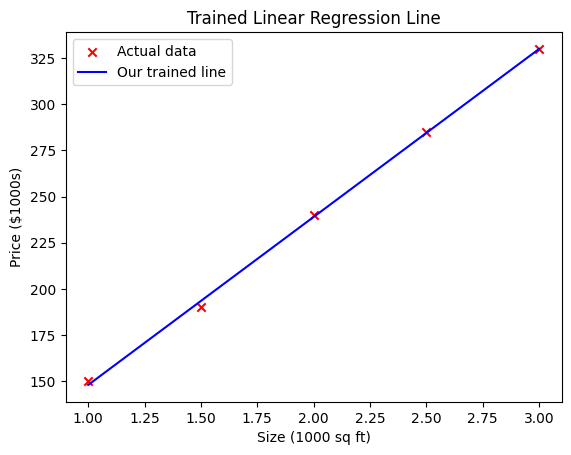

In [92]:
predicted_final = compute_model_output(x_train, w_final, b_final)

plt.scatter(x_train, y_train, marker='x', c='red', label='Actual data')
plt.plot(x_train, predicted_final, c='blue', label='Our trained line')
plt.title("Trained Linear Regression Line")
plt.xlabel("Size (1000 sq ft)")
plt.ylabel("Price ($1000s)")
plt.legend()
plt.show()

## Step 12: Predict the Price of a New House
Use the trained model on a house size it has never seen.

In [93]:
new_size = 2.6  # a house of size 2600 sq ft

predicted_price = compute_model_output(new_size, w_final, b_final)
print(f"Predicted price for a {new_size*1000:.0f} sq ft house: ${predicted_price*1000:.2f}")

Predicted price for a 2600 sq ft house: $293622.76


## Step 13: Plot Cost vs. Iterations
Visualize gradient descent converging to the minimum cost.

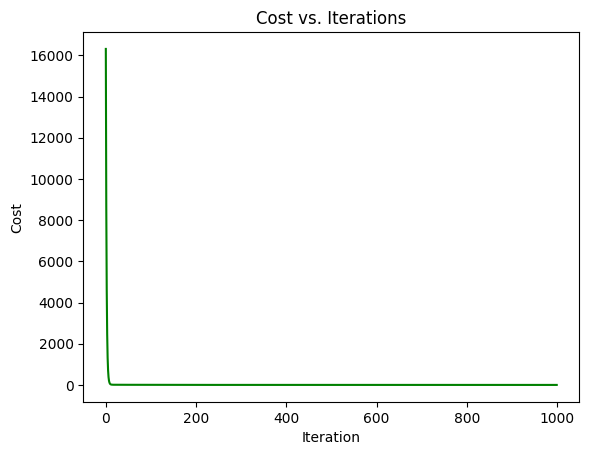

In [94]:
plt.plot(range(num_iters), cost_history, c='green')
plt.title("Cost vs. Iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

## Conclusion

- Implemented linear regression from scratch: `f(x) = wx + b`
- Defined and computed the cost function (MSE)
- Implemented gradient descent to learn optimal `w` and `b`
- Visualized the fitted regression line and cost convergence
- Used the trained model to predict a new house price

This covers the core Week-1 concepts: **linear regression, cost function, and gradient descent.**